In [44]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import numpy as np
import pickle

In [45]:
def load_dict_from_pickle(filename):
    try:
        with open(filename, 'rb') as f:
            data = pickle.load(f)
        return data
    except FileNotFoundError:
        print(f"Файл {filename} не найден.")
        return None
    except Exception as e:
        print(f"Ошибка при загрузке: {e}")
        return None

In [46]:
def plot_comparison(error, attack, metric, ylabel):
    fig, ax = plt.subplots(1, 2, figsize = (18, 9))
    
    styles = {
        'Нью-Йорк (сетчатая)': {'color': '#2ecc71', 'ls': '-', 'lw': 4},
        'Москва (кольцевая)': {'color': '#3498db', 'ls': '--', 'lw': 4},
        'Лондон (органическая)': {'color': '#f1c40f', 'ls': '-.', 'lw': 4},
        'Волгоград (линейная)': {'color': '#e74c3c', 'ls': ':', 'lw': 4}
    }   

    fractions = np.linspace(0, 1, 51)

    def process_axis(axis, data_dict):
        for city_name, data in data_dict.items():
            values = [np.mean(data[f][metric]) for f in fractions]
            style = styles.get(city_name)
            
            line, = axis.plot(fractions, values, label=city_name, **style)
            
            if metric == '<s>':
                idx_max = np.argmax(values)
                f_critical = fractions[idx_max]
                max_val = values[idx_max]
                
                axis.axvline(x=f_critical, color=style['color'], linestyle=':', alpha=0.6, lw=4)
                axis.scatter(f_critical, values[idx_max], color=style['color'], s=100, zorder=5)

                t = axis.text(f_critical, max_val * 1.02, f'{f_critical:.2f}', 
                              color=style['color'], 
                              fontsize=14, 
                              fontweight='bold',
                              ha='center', 
                              va='bottom')
                
                t.set_path_effects([
                    path_effects.withStroke(linewidth=3, foreground='white')
                ])

    process_axis(ax[0], error)
    process_axis(ax[1], attack)
    
    for a in ax:
        a.set_xlabel('Доля удаленных узлов', fontsize=20)
        a.set_ylabel(ylabel, fontsize=20)
        a.grid(True, which='both', ls='--', alpha=0.5)
        a.tick_params(axis='both', which='major', labelsize=18)
        a.set_xlim(0, 1)
        a.set_ylim(0, None)
    
    handles, labels = ax[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1),
               ncol=4, fontsize=20, frameon=True)

    plt.tight_layout()
    return fig

## Загрузка

In [47]:
Moscow_error = load_dict_from_pickle("./Stats/Moscow_error.pkl")
Moscow_attack = load_dict_from_pickle("./Stats/Moscow_attack.pkl")

New_York_error = load_dict_from_pickle("./Stats/New_York_error.pkl")
New_York_attack = load_dict_from_pickle("./Stats/New_York_attack.pkl")

Volgograd_error = load_dict_from_pickle("./Stats/Volgograd_error.pkl")
Volgograd_attack = load_dict_from_pickle("./Stats/Volgograd_attack.pkl")

London_error = load_dict_from_pickle("./Stats/London_error.pkl")
London_attack = load_dict_from_pickle("./Stats/London_attack.pkl")

## Визуализация

In [48]:
error = {
    'Нью-Йорк (сетчатая)': New_York_error,
    'Москва (кольцевая)': Moscow_error,
    'Лондон (органическая)': London_error,
    'Волгоград (линейная)': Volgograd_error
}

attack = {
    'Нью-Йорк (сетчатая)': New_York_attack,
    'Москва (кольцевая)': Moscow_attack,
    'Лондон (органическая)': London_attack,
    'Волгоград (линейная)': Volgograd_attack
}

### GCC (Giant Connected Component)

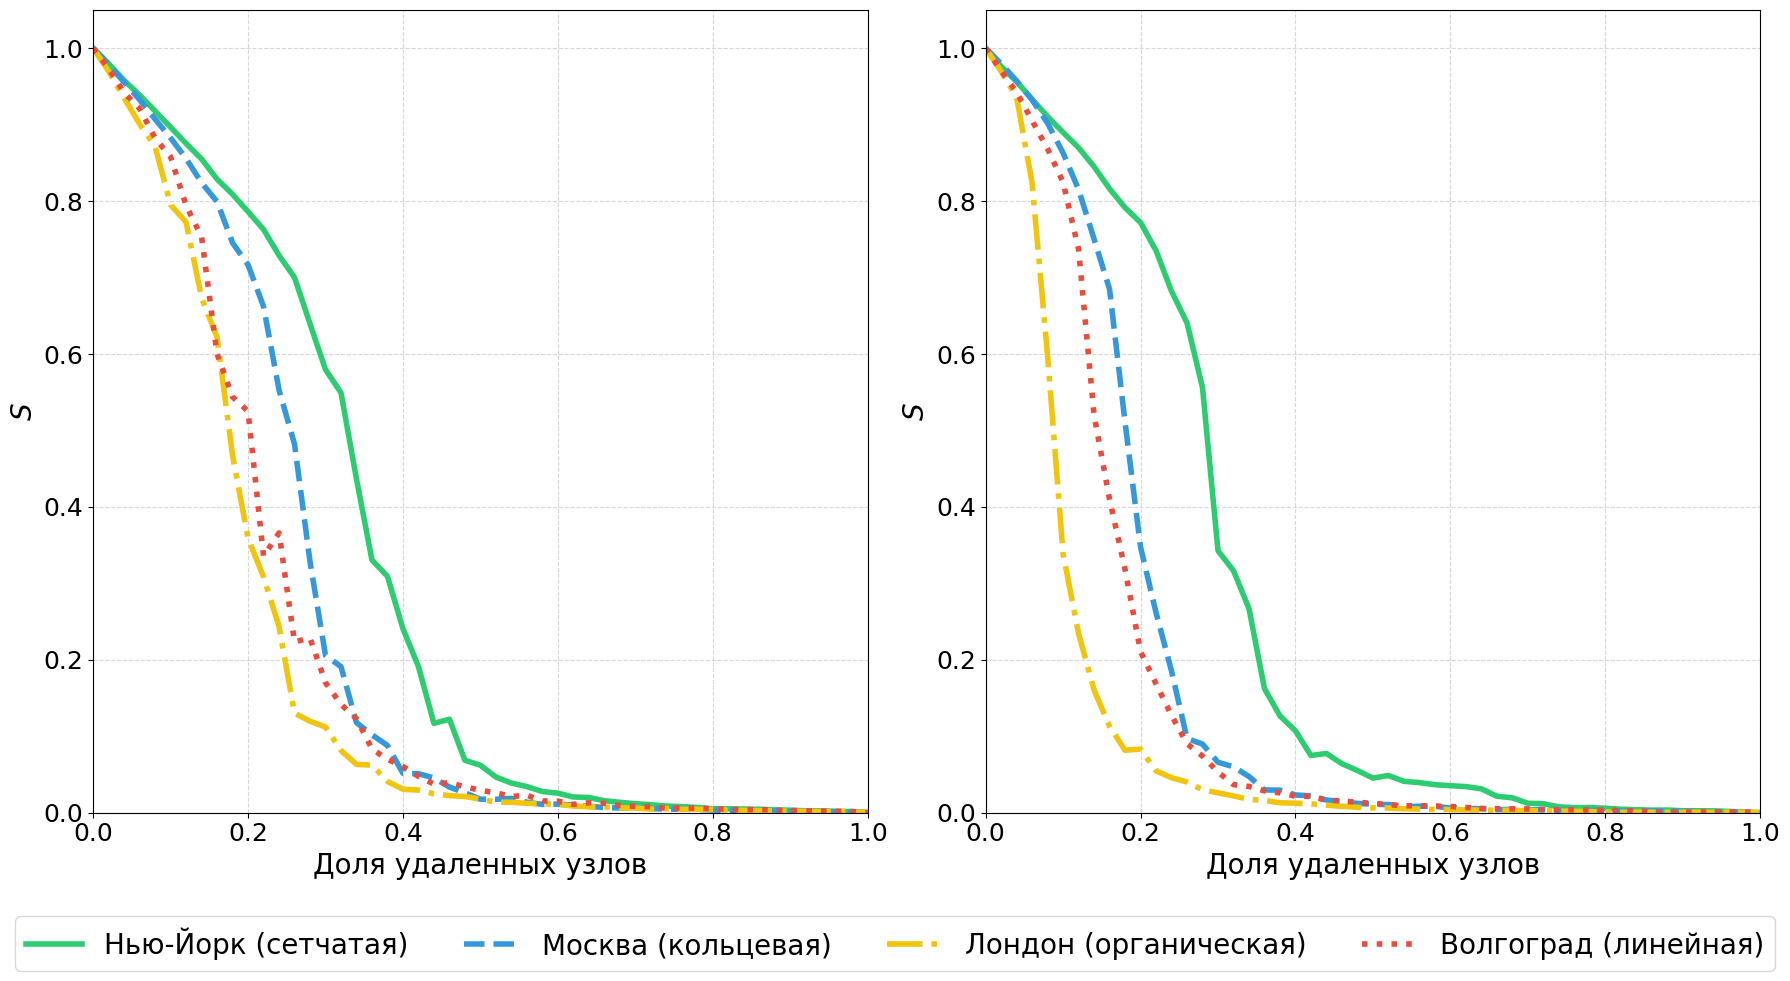

In [49]:
fig = plot_comparison(error, attack, "S", "$S$")

In [50]:
fig.savefig(
    './Graphics/S.png', 
    dpi=300,           
    bbox_inches='tight', 
    pad_inches=0.1,      
    transparent=False,   
    facecolor='white'
)

### Average Size of Isolated Clusters

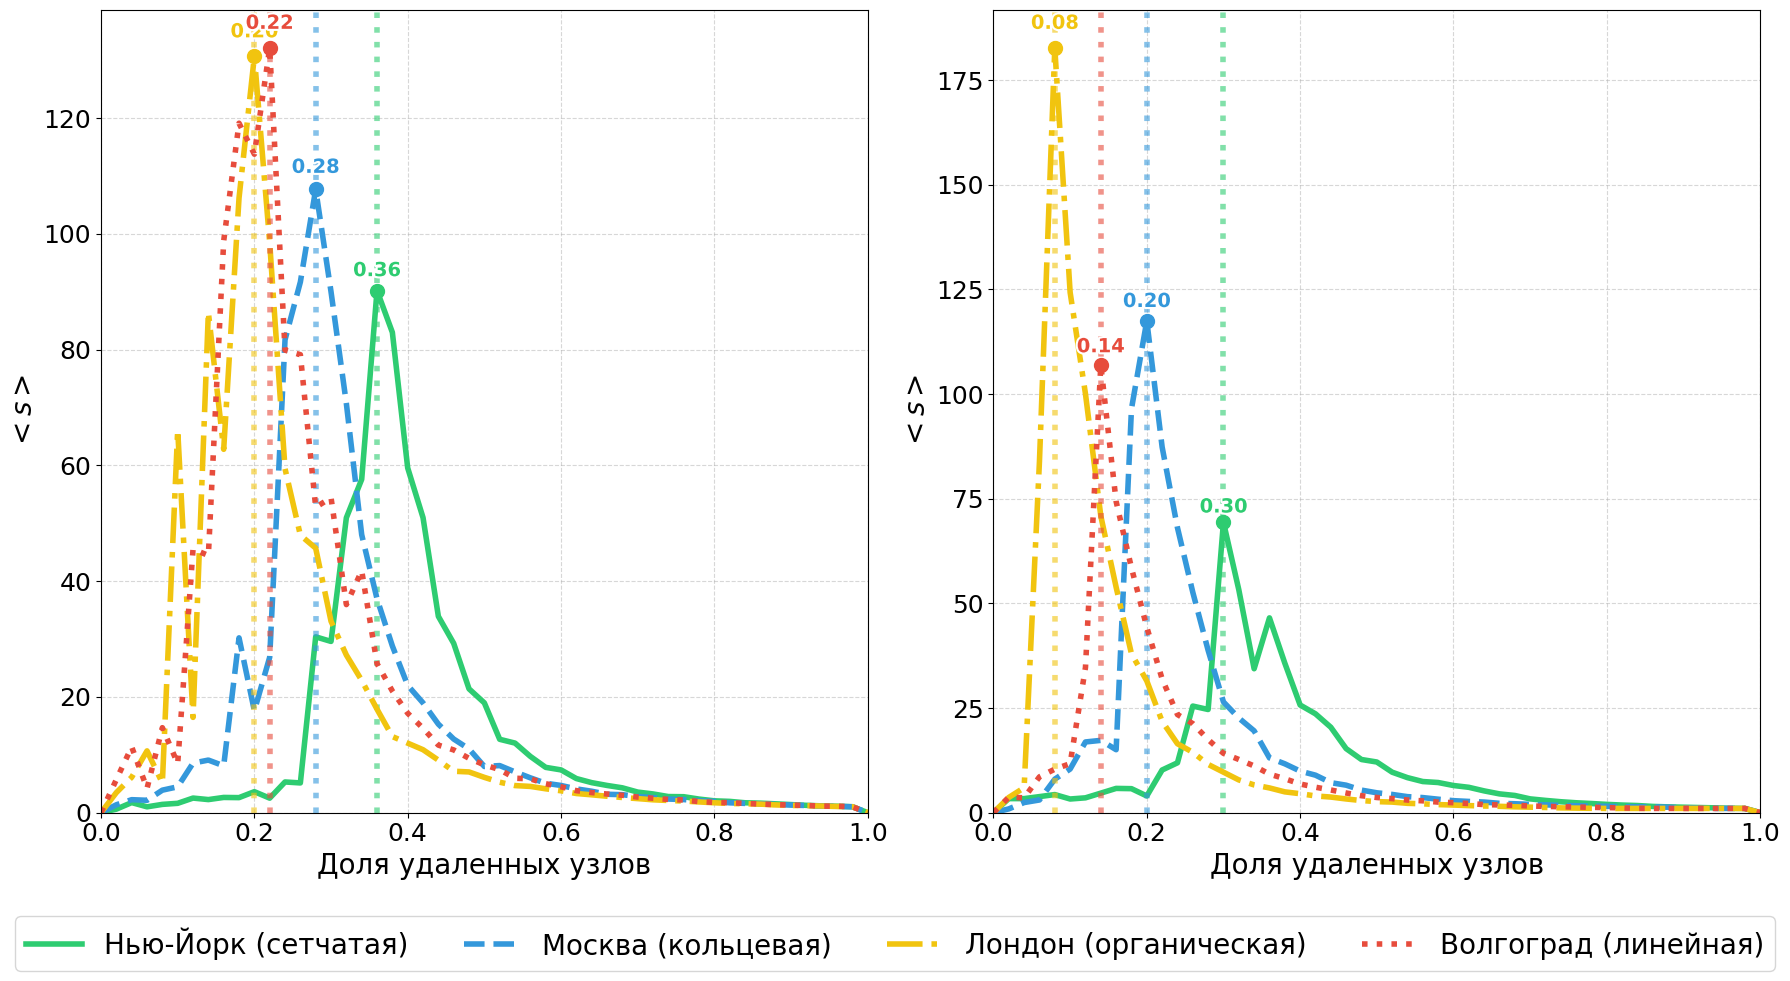

In [51]:
fig = plot_comparison(error, attack, "<s>", "$<s>$")

In [52]:
fig.savefig(
    './Graphics/avg_s.png', 
    dpi=300,           
    bbox_inches='tight', 
    pad_inches=0.1,      
    transparent=False,   
    facecolor='white'
)

### Topological Diameter

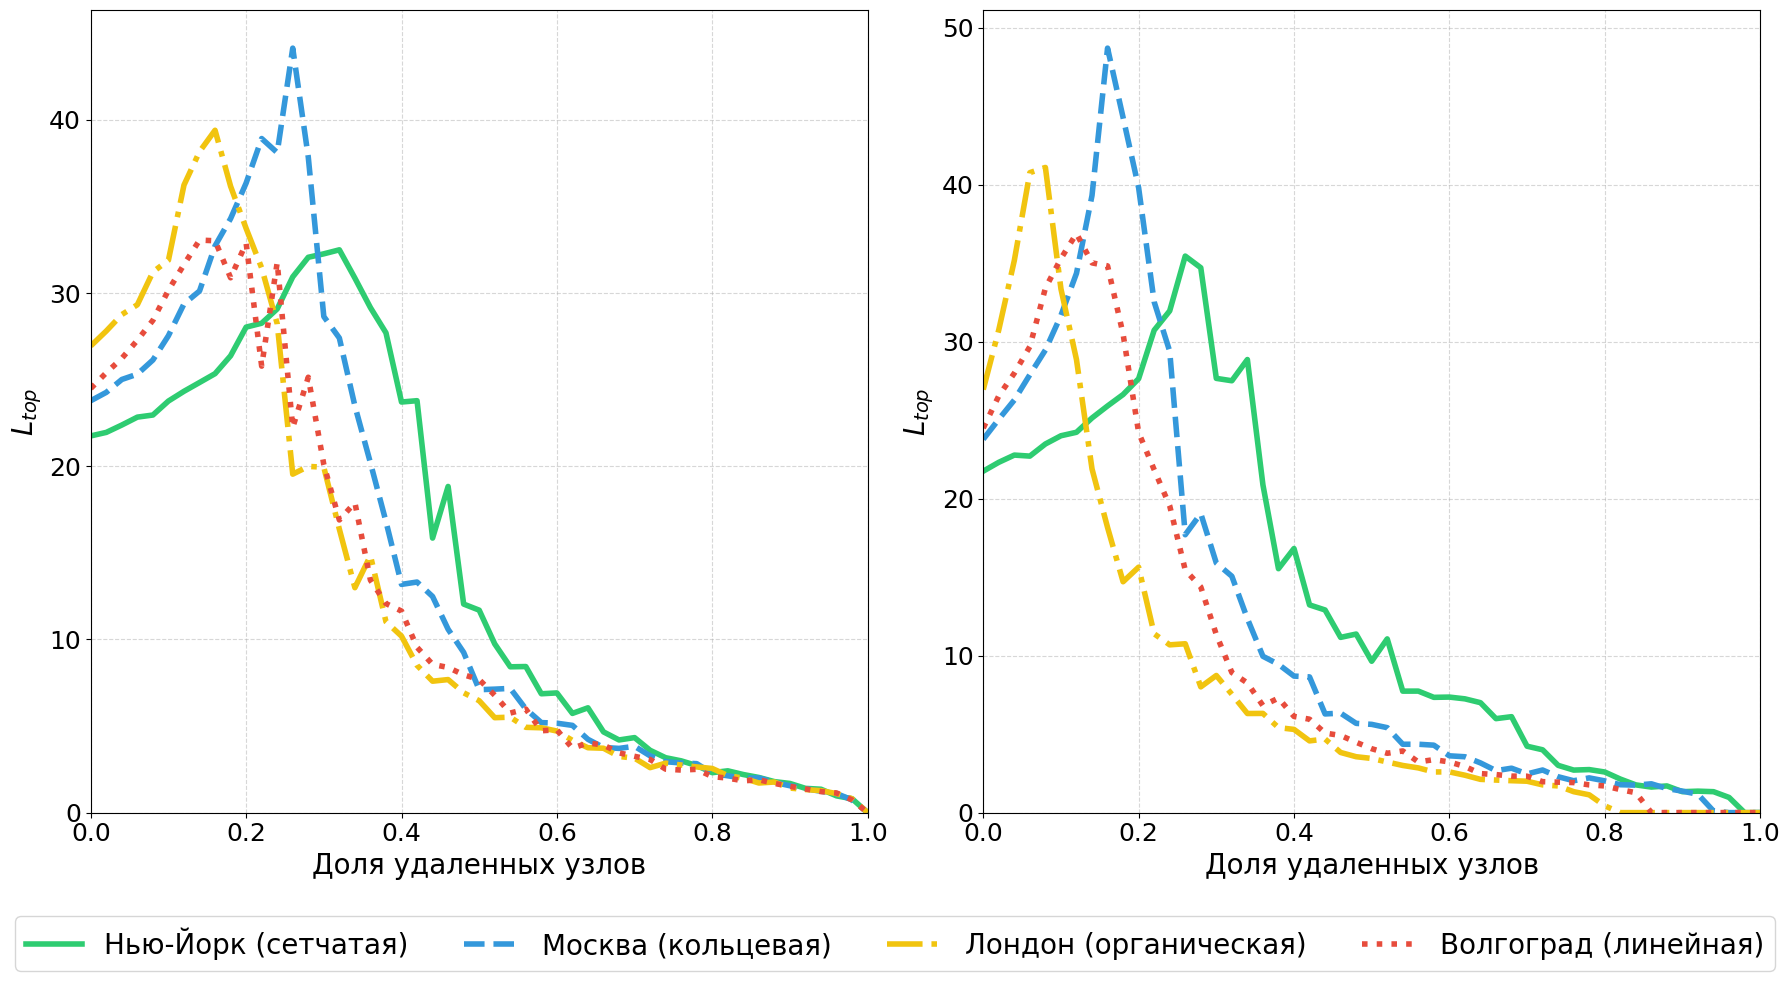

In [53]:
fig = plot_comparison(error, attack, "L_top", "$L_{top}$")

In [54]:
fig.savefig(
    './Graphics/L_top.png', 
    dpi=300,           
    bbox_inches='tight', 
    pad_inches=0.1,      
    transparent=False,   
    facecolor='white'
)

### Length Diameter

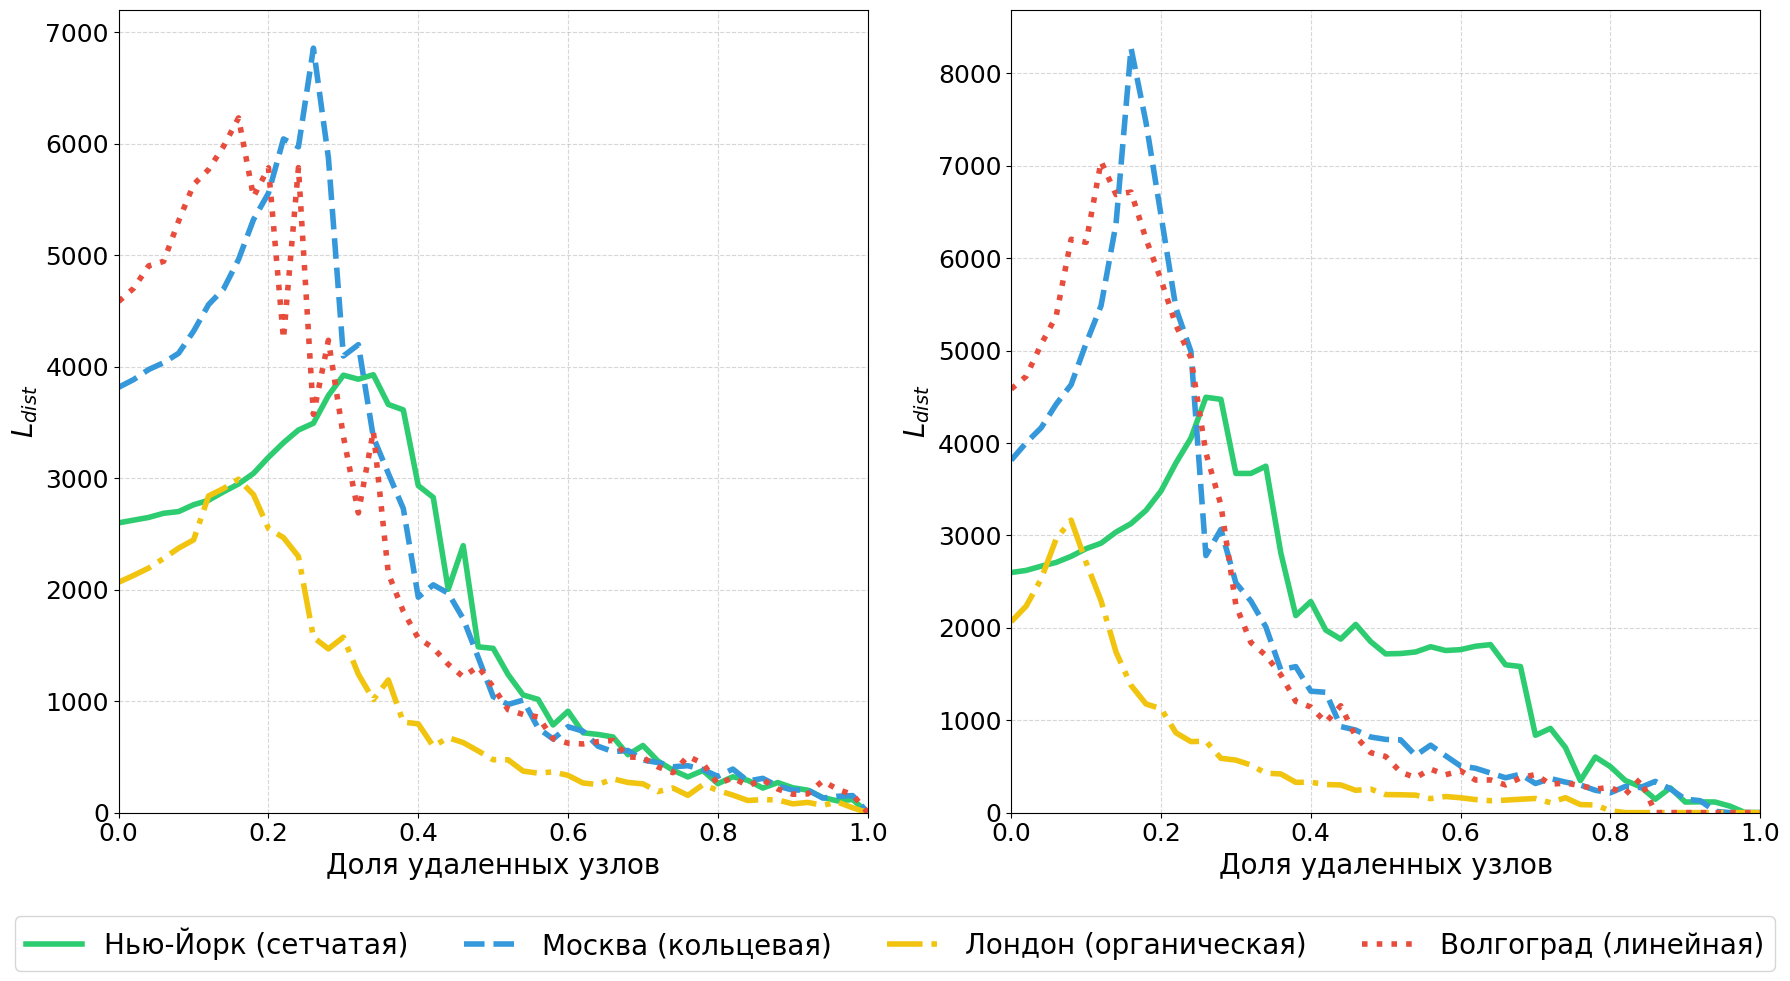

In [55]:
fig = plot_comparison(error, attack, "L_dist", "$L_{dist}$")

In [56]:
fig.savefig(
    './Graphics/L_dist.png', 
    dpi=300,           
    bbox_inches='tight', 
    pad_inches=0.1,      
    transparent=False,   
    facecolor='white'
)

### Global Efficiency

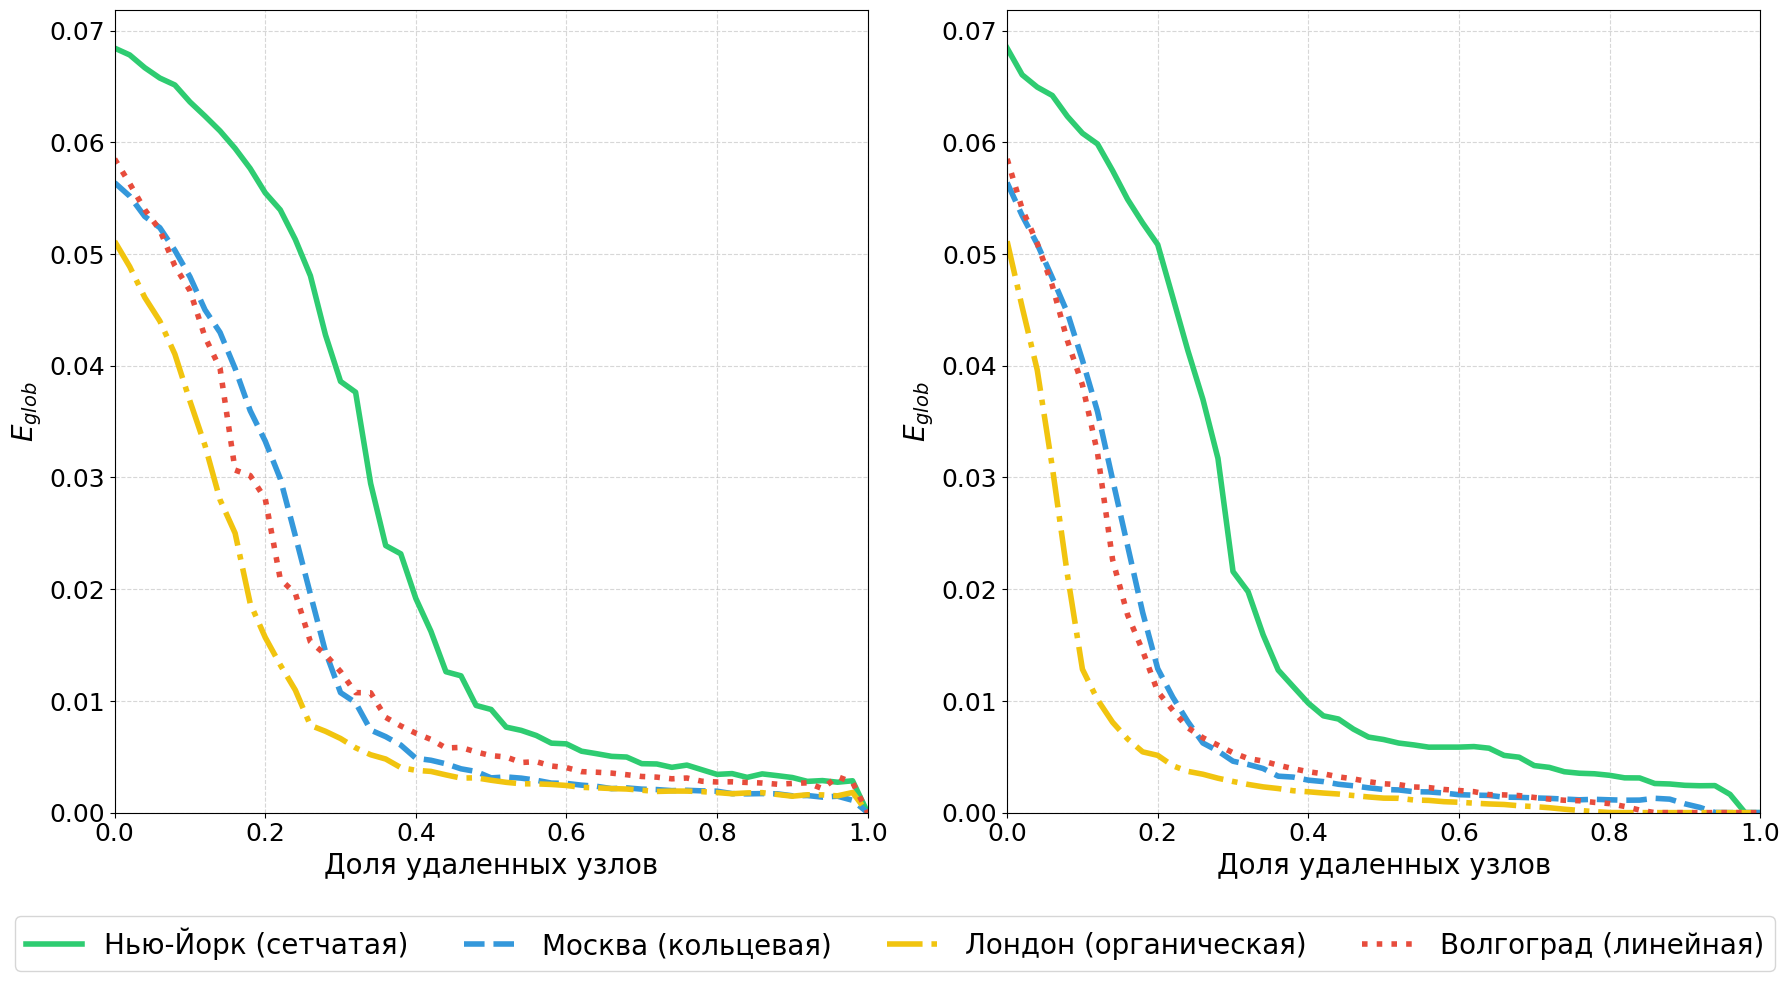

In [57]:
fig = plot_comparison(error, attack, "E", "$E_{glob}$")

In [58]:
fig.savefig(
    './Graphics/E.png', 
    dpi=300,           
    bbox_inches='tight', 
    pad_inches=0.1,      
    transparent=False,   
    facecolor='white'
)

### Local Clustering Coefficient

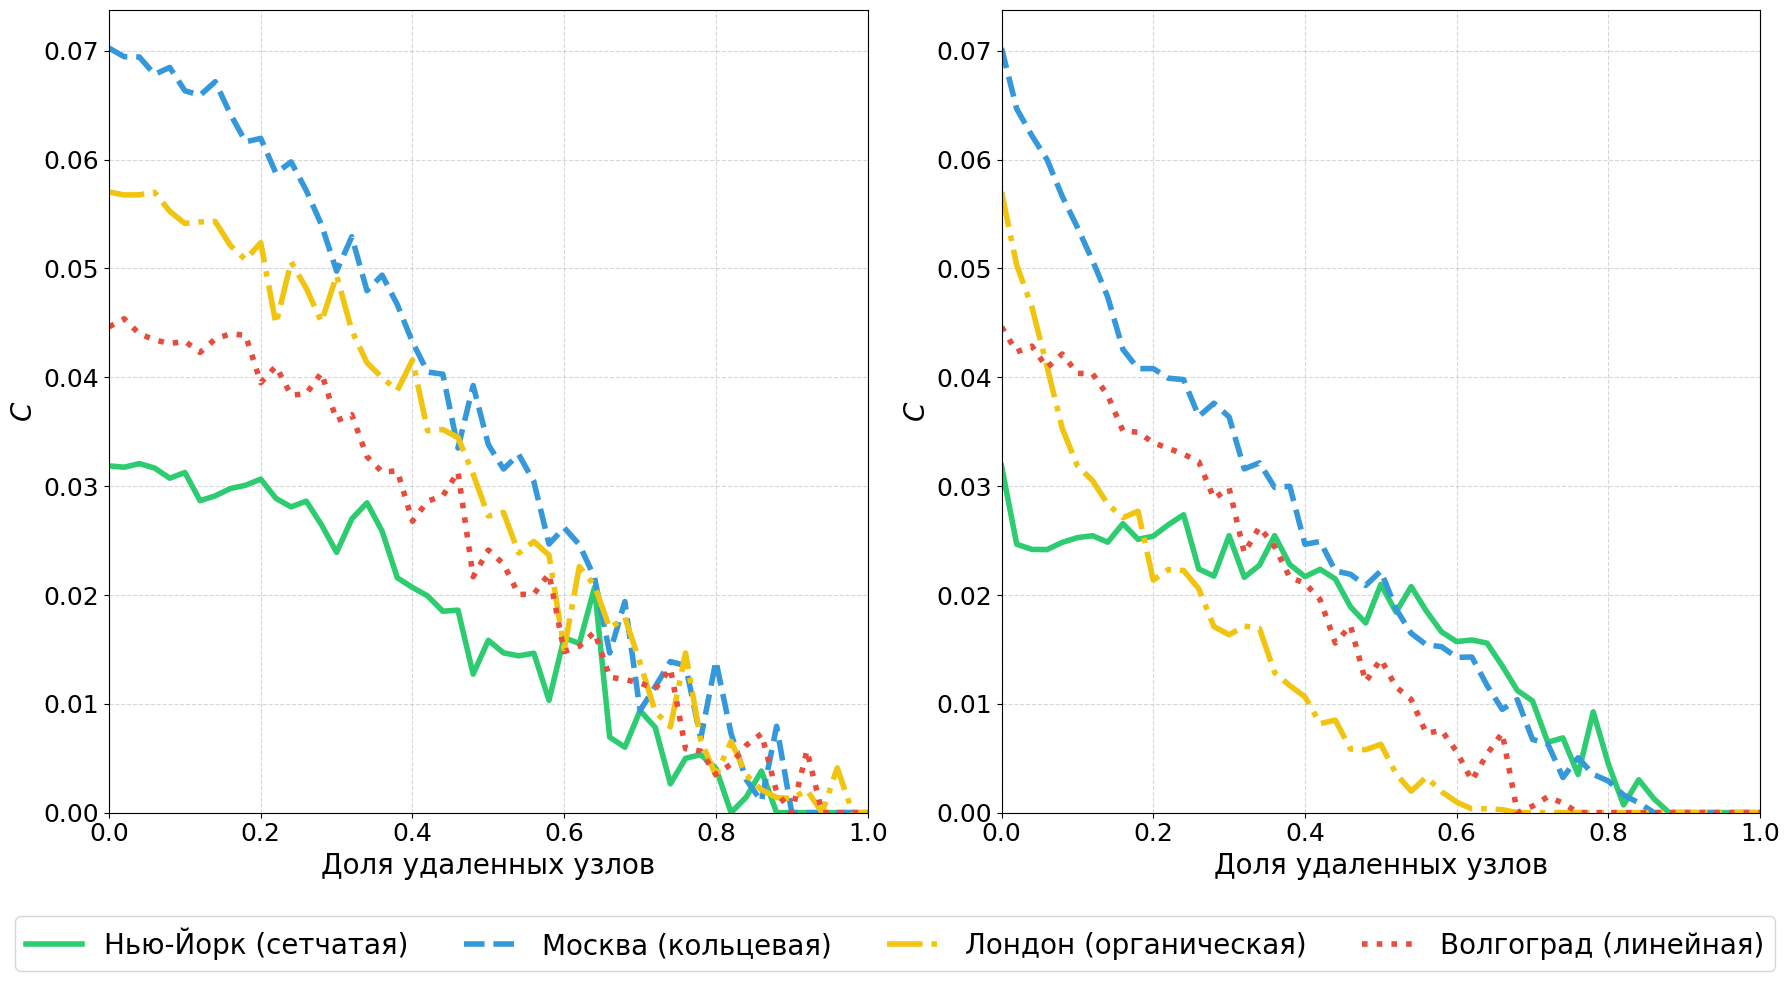

In [59]:
fig = plot_comparison(error, attack, "C", "$C$")

In [60]:
fig.savefig(
    './Graphics/C.png', 
    dpi=300,           
    bbox_inches='tight', 
    pad_inches=0.1,      
    transparent=False,   
    facecolor='white'
)